# Sideview glancing incidence: Fresnel multislice and a single-plane Rayleigh–Sommerfeld model

This notebook compares two deliberately different descriptions of the same glancing-incidence silicon slab. The Fresnel calculation keeps the depth-resolved potential and propagates the wave one short slice at a time. The 1D Rayleigh–Sommerfeld-style calculation first collapses the entire slab into one potential along the surface, applies it once, and uses a cylindrical Green-function propagator to reach the output.

The comparison is qualitative. In particular, the single-plane model has no fitted amplitude factor. Its value here is to show the limitation of collapsing a periodic, depth-resolved crystal before propagation: the Fresnel multislice calculation retains much stronger and more structured Bragg features in the exit-wave angular spectrum.

In [44]:
import importlib

import abtem
from ase.build import bulk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import wide_angle_propagation.propagation_methods as propagation_methods

# Reload the local source when developing from this repository.
propagation_methods = importlib.reload(propagation_methods)

from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel_1d,
    energy2wavelength,
    fourier_propagate_1d,
    simulate_glancing_fresnel_baseline_1d,
    simulate_single_slice_cylindrical_1d,
)
from wide_angle_propagation.sideview_geometry import line_from_angle, make_tilted_gaussian_beam_1d

abtem.config.set({"device": "cpu", "precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Geometry and the atomistic potential

`s` is the direction along the surface, and `u` is the transverse direction. The top surface is at `u = 0`, and the slab extends to negative `u`. abTEM supplies one projected silicon unit-cell potential in the sideview plane; repeating that cell produces a periodic crystal potential. The periodicity along `s` is the ingredient that can produce Bragg diffraction.

The next cell also checks the sampling. It requires the transverse Nyquist frequency to contain the incident tilt plus the first lattice spatial frequency, resolves one lattice period by several samples, and checks that the Fresnel transfer-function phase remains modest at the Nyquist limit. These are conservative checks for the incident beam and first-order Bragg physics, rather than a claim that every atomic high-angle feature is converged.

The incident Gaussian is tilted down towards the surface. Its centre is chosen to cross `u = 0` halfway through the slab.

In [45]:
energy_eV = 30e3
slab_length_A = 1_000.0
slab_depth_A = 50.0
vacuum_margin_A = 120.0
glancing_angle_deg = 2.0
input_tilt = -float(np.deg2rad(glancing_angle_deg))
beam_waist_A = 3.0

si_lattice_A = 5.431
si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
si_unit.pbc = [True, True, True]
potential_builder = abtem.Potential(
    si_unit, sampling=0.35, slice_thickness=float(si_unit.cell.lengths()[1]),
    projection="finite", parametrization="lobato", plane="xz", device="cpu",
)
unit_potential = np.asarray(potential_builder.build(lazy=False).array)[0] / float(si_unit.cell.lengths()[1])
du, ds = (float(value) for value in potential_builder.sampling)
wavelength_A = float(energy2wavelength(energy_eV))

n_steps = int(np.ceil(slab_length_A / ds))
n_u = int(np.ceil((slab_depth_A + 2 * vacuum_margin_A) / du))
if n_u % 2:
    n_u += 1
u = (jnp.arange(n_u) - n_u // 2) * du
s = jnp.arange(n_steps) * ds
beam_center_A = -0.5 * slab_length_A * np.tan(input_tilt)

# Sampling checks for the incident beam and the first-order lattice diffraction.
transverse_nyquist_Ainv = 1.0 / (2.0 * du)
tilt_frequency_Ainv = abs(np.sin(input_tilt)) / wavelength_A
first_bragg_frequency_Ainv = 1.0 / si_lattice_A
required_frequency_Ainv = tilt_frequency_Ainv + first_bragg_frequency_Ainv
samples_per_lattice_period = si_lattice_A / ds
fresnel_nyquist_phase_rad = np.pi * wavelength_A * ds * transverse_nyquist_Ainv**2
max_detector_angle_mrad = 1e3 * np.arcsin(np.clip(wavelength_A * transverse_nyquist_Ainv, -1.0, 1.0))

assert required_frequency_Ainv < 0.8 * transverse_nyquist_Ainv, (
    "Transverse sampling cannot represent the incident beam and first Bragg order with margin."
)
assert samples_per_lattice_period >= 8.0, "The propagation direction needs at least eight samples per Si lattice period."
assert fresnel_nyquist_phase_rad < 0.5, "Reduce ds or increase du: the Fresnel phase changes too quickly at Nyquist."

{
    "unit-cell potential shape": unit_potential.shape,
    "multislice grid shape": (n_steps, n_u),
    "electron wavelength (A)": wavelength_A,
    "tilt + first Bragg frequency / Nyquist": required_frequency_Ainv / transverse_nyquist_Ainv,
    "samples per Si lattice period": samples_per_lattice_period,
    "Fresnel Nyquist phase (rad)": fresnel_nyquist_phase_rad,
    "maximum detector angle (mrad)": max_detector_angle_mrad,
}

{'unit-cell potential shape': (16, 16),
 'multislice grid shape': (2947, 856),
 'electron wavelength (A)': 0.06979081544914424,
 'tilt + first Bragg frequency / Nyquist': 0.4644772746447521,
 'samples per Si lattice period': 16.0,
 'Fresnel Nyquist phase (rad)': 0.1614835670064979,
 'maximum detector angle (mrad)': 102.98557984022744}

## Fresnel multislice reference

The first calculation is the reference in this notebook. At every step it multiplies the wave by the phase from the local potential `V(s, u)` and then Fresnel-propagates by `ds`. The potential therefore remains depth resolved throughout the calculation.

The cyan points in the plot below are atom positions shown only as a guide to the periodic geometry. A short vacuum gap is added before the comparison plane, which keeps every Rayleigh–Sommerfeld source-target pair well inside its high-frequency regime.

In [46]:
def tile_to_shape(array, shape):
    repetitions = tuple(int(np.ceil(target / size)) for target, size in zip(shape, array.shape))
    return np.tile(array, repetitions)[tuple(slice(0, target) for target in shape)]

n_slab_u = int(np.ceil(slab_depth_A / du))
u_stop = int(np.searchsorted(np.asarray(u), 0.0, side="right"))
u_start = u_stop - n_slab_u
if u_start < 0:
    raise ValueError("Increase vacuum_margin_A so the slab fits on the transverse grid.")

# unit_potential is indexed as (u, s); potential_slices is indexed as (s, u).
potential_slices_np = np.zeros((n_steps, n_u), dtype=np.float64)
potential_slices_np[:, u_start:u_stop] = tile_to_shape(unit_potential, (n_slab_u, n_steps)).T
potential_slices = jnp.asarray(potential_slices_np)

input_wave = jnp.exp(-0.5 * ((u - beam_center_A) / beam_waist_A) ** 2).astype(jnp.complex128)
fresnel_wave, _, fresnel_diagnostics = simulate_glancing_fresnel_baseline_1d(
    input_wave, potential_slices, du, ds, energy_eV, input_tilt=input_tilt
)
fresnel_intensity = jnp.abs(fresnel_diagnostics["wavefronts"]) ** 2
comparison_gap_A = 20.0
fresnel_comparison_wave = fourier_propagate_1d(
    fresnel_wave, angular_spectrum_propagation_kernel_1d(n_u, du, comparison_gap_A, energy_eV)
)

# Atom markers are visual only; they do not enter the calculation separately.
atom_s, atom_u = [], []
for depth_tile in range(int(np.ceil(slab_depth_A / si_lattice_A)) + 1):
    for path_tile in range(int(np.ceil(slab_length_A / si_lattice_A)) + 1):
        atom_u.append(-slab_depth_A + si_unit.positions[:, 0] + depth_tile * si_lattice_A)
        atom_s.append(si_unit.positions[:, 2] + path_tile * si_lattice_A)
atom_u = np.concatenate(atom_u)
atom_s = np.concatenate(atom_s)
inside = (atom_u >= -slab_depth_A) & (atom_u <= 0) & (atom_s >= 0) & (atom_s <= slab_length_A)
atom_u, atom_s = atom_u[inside], atom_s[inside]

assert jnp.all(jnp.isfinite(fresnel_wave))
assert jnp.all(jnp.isfinite(fresnel_intensity))

## Single-plane Rayleigh–Sommerfeld-style approximation

For the second calculation, the crystal is compressed along `u` into one effective surface potential `V_eff(s)`. We form it as a depth-weighted sum of the atomistic potential: shallow material contributes most, and the contribution decreases exponentially with depth. A normalized forward Rayleigh–Sommerfeld kernel propagates the incident field to this surface line, the effective phase is applied once, and the same kernel propagates the result to the output line.

The Rayleigh–Sommerfeld kernel includes its inverse-square-root amplitude, wavelength-dependent prefactor, and obliquity factor. The surface normal is chosen towards positive `u`, so the second propagation retains only the vacuum-side, reflected half-space. This construction still removes the alternating propagation and scattering that the multislice calculation performs inside the crystal, so it tests the single-plane approximation rather than an arbitrary Green-function scale factor.

In [47]:
# The Rayleigh–Sommerfeld model receives one potential along the surface line.
# This simple depth sum is an explicit approximation, not a fitted source or scattering correction.
penetration_depth_A = 30.0
depth_A = -np.asarray(u[u_start:u_stop])
depth_weights = np.exp(-depth_A / penetration_depth_A)
effective_potential_s = jnp.asarray(
    np.sum(potential_slices_np[:, u_start:u_stop] * depth_weights[None, :], axis=1) * du
)

# Keep the input line a short distance before the surface line, avoiding coincident source and target points.
input_gap_A = 80.0
rs_min_kR = 2.0 * np.pi * min(input_gap_A, comparison_gap_A) / wavelength_A
assert rs_min_kR > 50.0, "Increase the vacuum gaps so the high-frequency RS kernel is accurate."
rs_input_line = line_from_angle(jnp.array([0.0, -input_gap_A]), 0.0, u)
surface_line = line_from_angle(jnp.array([0.0, 0.0]), jnp.pi / 2.0, s)
output_line = line_from_angle(jnp.array([0.0, slab_length_A + comparison_gap_A]), 0.0, u)
rs_beam_center_A = -(0.5 * slab_length_A + input_gap_A) * np.tan(input_tilt)
rs_input_wave = make_tilted_gaussian_beam_1d(
    u, energy_eV, waist=beam_waist_A, center=rs_beam_center_A, tilt=input_tilt
).astype(jnp.complex128)

rs_wave, _, _ = simulate_single_slice_cylindrical_1d(
    rs_input_wave, rs_input_line, surface_line, output_line, effective_potential_s, energy_eV,
    sample_normal=jnp.array([1.0, 0.0]),
)
assert jnp.all(jnp.isfinite(rs_wave))
{"minimum kR used by the RS kernel": rs_min_kR}

{'minimum kR used by the RS kernel': 1800.5765563115021}

## Comparison

The left panel is the Fresnel multislice propagation through the atomistic slab. The other panels compare the exit intensity and the angular spectrum. Every panel uses raw sampled intensity, so the relative energy in the two calculations remains visible. The line-integrated scalar intensities are reported below the figure.

In this geometry, the Fresnel far field contains the richer set of Bragg-related peaks. The single-plane model does not reproduce that structure well, which indicates that the depth-resolved propagation is important here.

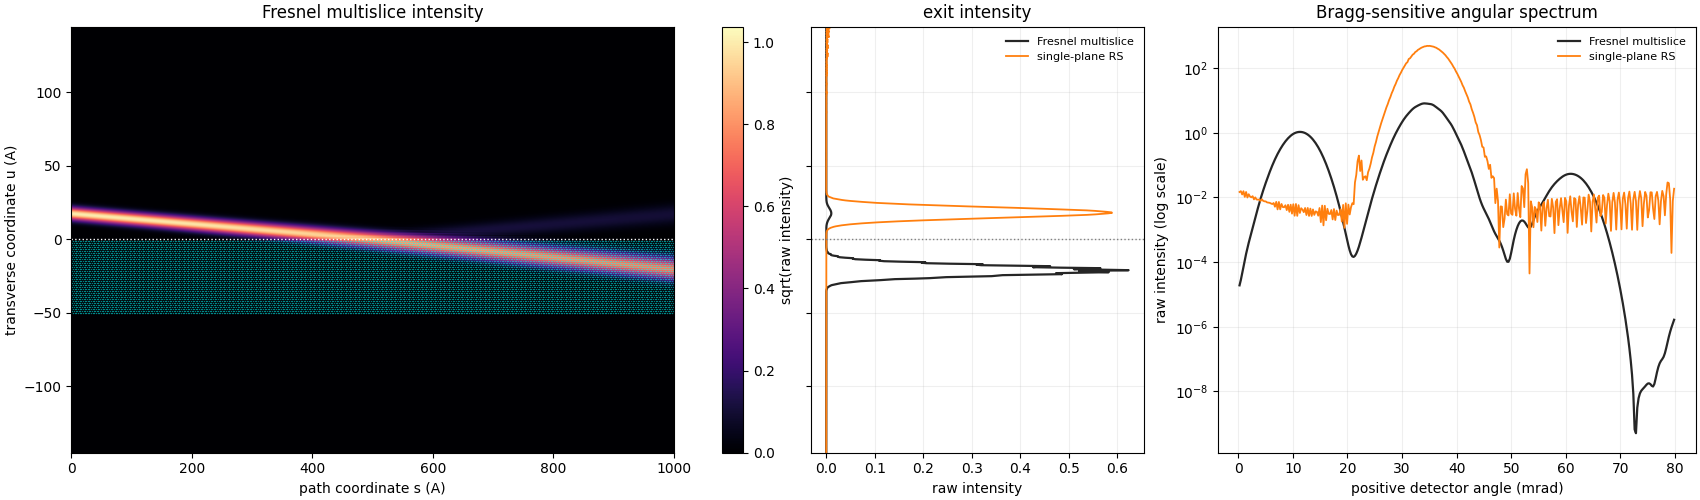

{'Fresnel exit-line integral (raw scalar units)': 5.317361552716189,
 'single-plane RS exit-line integral (raw scalar units)': 5.326576521877585}

In [48]:
fresnel_display = np.sqrt(np.asarray(fresnel_intensity))
fresnel_exit = np.asarray(jnp.abs(fresnel_comparison_wave) ** 2)
rs_exit = np.asarray(jnp.abs(rs_wave) ** 2)
fresnel_farfield = np.asarray(jnp.abs(jnp.fft.fftshift(jnp.fft.fft(fresnel_comparison_wave))) ** 2)
rs_farfield = np.asarray(jnp.abs(jnp.fft.fftshift(jnp.fft.fft(rs_wave))) ** 2)
detector_angle_mrad = 1e3 * np.arcsin(np.clip(np.fft.fftshift(np.fft.fftfreq(n_u, d=du)) * wavelength_A, -1, 1))

# Share the physical u axis between the propagation map and exit profile.
# This makes the profile's vertical position directly comparable with the map.
fig = plt.figure(figsize=(17, 5), constrained_layout=True)
grid = fig.add_gridspec(1, 3, width_ratios=(1.45, 0.8, 1.15))
ax_map = fig.add_subplot(grid[0, 0])
ax_exit = fig.add_subplot(grid[0, 1], sharey=ax_map)
ax_far = fig.add_subplot(grid[0, 2])
extent = [float(s[0]), float(s[-1] + ds), float(u[0]), float(u[-1])]
# `aspect="auto"` keeps this panel's shared u axis pixel-aligned with the exit profile.
image = ax_map.imshow(fresnel_display.T, extent=extent, origin="lower", aspect="auto", cmap="magma")
ax_map.scatter(atom_s, atom_u, s=1, color="cyan", alpha=0.5, linewidths=0, rasterized=True)
ax_map.axhline(0, color="white", ls=":", lw=1)
ax_map.set(xlabel="path coordinate s (A)", ylabel="transverse coordinate u (A)", title="Fresnel multislice intensity")
fig.colorbar(image, ax=ax_map, label="sqrt(raw intensity)")

ax_exit.plot(fresnel_exit, np.asarray(u), color="0.15", lw=1.6, label="Fresnel multislice")
ax_exit.plot(rs_exit, np.asarray(u), color="tab:orange", lw=1.3, label="single-plane RS")
ax_exit.axhline(0, color="0.5", ls=":", lw=1)
ax_exit.set(xlabel="raw intensity", title="exit intensity")
ax_exit.tick_params(axis="y", labelleft=False)
ax_exit.grid(alpha=0.2)
ax_exit.legend(frameon=False, fontsize=8)

visible = (detector_angle_mrad > 0) & (detector_angle_mrad < 80)
ax_far.semilogy(detector_angle_mrad[visible], fresnel_farfield[visible] + 1e-30, color="0.15", lw=1.6, label="Fresnel multislice")
ax_far.semilogy(detector_angle_mrad[visible], rs_farfield[visible] + 1e-30, color="tab:orange", lw=1.3, label="single-plane RS")
ax_far.set(xlabel="positive detector angle (mrad)", ylabel="raw intensity (log scale)", title="Bragg-sensitive angular spectrum")
ax_far.grid(alpha=0.2)
ax_far.legend(frameon=False, fontsize=8)
plt.show()

{
    "Fresnel exit-line integral (raw scalar units)": float(du * np.sum(fresnel_exit)),
    "single-plane RS exit-line integral (raw scalar units)": float(du * np.sum(rs_exit)),
}

## Takeaway

The single-plane calculation is useful as a compact Rayleigh–Sommerfeld-style approximation, but it is not interchangeable with depth-resolved Fresnel multislice propagation for this periodic slab. Compressing the potential into one surface line loses the sequence of scattering and propagation events that builds the Bragg structure.